In [1]:
# Sports Betting Legalization Analysis
# Notebook 01: Data Exploration

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set styling
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.family'] = 'Arial'

print("Libraries loaded successfully")
print(f"Pandas version: {pd.__version__}")

Libraries loaded successfully
Pandas version: 2.3.3


In [2]:
# Load both Excel files
import os

# File paths — update these if your folder structure is different
data_folder = "../data"  # Going up one level from notebooks/ into data/
actuals_path = os.path.join(data_folder, "sports_betting_actuals_v2.xlsx")
projections_path = os.path.join(data_folder, "sports_betting_projections_v2.xlsx")

# Load the data
actuals = pd.read_excel(actuals_path)
projections = pd.read_excel(projections_path)

print("Actuals data loaded:")
print(actuals)
print("\n" + "="*60 + "\n")
print("Projections data loaded:")
print(projections)

FileNotFoundError: [Errno 2] No such file or directory: '../data\\sports_betting_actuals_v2.xlsx'

In [3]:
import os

# Where is the notebook running from?
print("Current working directory:")
print(os.getcwd())

# What files/folders are visible from here?
print("\nFiles and folders in current directory:")
for item in os.listdir():
    print(f"  {item}")

Current working directory:
C:\Users\xboxo\anaconda_projects\3d0008df-eff5-40ee-bd9c-2c11beb739f2

Files and folders in current directory:
  .ipynb_checkpoints
  SportsBetting.ipynb


In [4]:
import os

# Search common locations for your Excel files
locations_to_check = [
    r"C:\Users\xboxo\Downloads",
    r"C:\Users\xboxo\Documents",
    r"C:\Users\xboxo\Desktop",
    r"C:\Users\xboxo\Documents\sports_betting_analysis",
    r"C:\Users\xboxo\Desktop\sports_betting_analysis",
    r"C:\Users\xboxo\sports_betting_analysis",
]

for location in locations_to_check:
    if os.path.exists(location):
        files = os.listdir(location)
        excel_files = [f for f in files if f.endswith('.xlsx')]
        if excel_files:
            print(f"\n✓ Found Excel files in: {location}")
            for f in excel_files:
                print(f"    {f}")
        # Check for sports_betting_analysis subfolder
        if "sports_betting_analysis" in files:
            sub_path = os.path.join(location, "sports_betting_analysis")
            print(f"\n✓ Found sports_betting_analysis folder at: {sub_path}")


✓ Found Excel files in: C:\Users\xboxo\Downloads
    sports_betting_actuals_v2.xlsx
    sports_betting_projections_v2.xlsx


In [5]:
# Direct paths to the Excel files
actuals_path = r"C:\Users\xboxo\Downloads\sports_betting_actuals_v2.xlsx"
projections_path = r"C:\Users\xboxo\Downloads\sports_betting_projections_v2.xlsx"

# Load the data
actuals = pd.read_excel(actuals_path)
projections = pd.read_excel(projections_path)

print("Actuals data loaded:")
print(actuals)
print("\n" + "="*60 + "\n")
print("Projections data loaded:")
print(projections)

Actuals data loaded:
               State Online Launch Date  Tax Rate  Total Handle ($M)  \
0           New York         2022-01-08      0.51            83000.0   
1         New Jersey         2018-08-01      0.13            60000.0   
2            Arizona         2021-09-09      0.15            25000.0   
3     North Carolina         2024-03-11      0.18            13500.0   
4           Maryland         2022-11-23      0.15            18000.0   
5           Virginia         2021-01-21      0.15            28000.0   
6                NaN                NaT       NaN                NaN   
7  TOTALS / AVERAGES                NaT       NaN           227500.0   

   Total Revenue ($M)  Total Tax Revenue ($M)  Effective Hold %  \
0              7100.0                  3600.0          0.085542   
1              4500.0                   560.0          0.075000   
2              2200.0                   220.0          0.088000   
3              1500.0                   270.0          0.11111

In [6]:
# Quick data inspection
print("ACTUALS — shape and columns:")
print(f"Rows: {actuals.shape[0]}, Columns: {actuals.shape[1]}")
print(f"Column names: {list(actuals.columns)}")
print()

print("PROJECTIONS — shape and columns:")
print(f"Rows: {projections.shape[0]}, Columns: {projections.shape[1]}")
print(f"Column names: {list(projections.columns)}")
print()

# Check for missing data
print("Any missing values in actuals?")
print(actuals.isnull().sum())
print()
print("Any missing values in projections?")
print(projections.isnull().sum())

ACTUALS — shape and columns:
Rows: 8, Columns: 10
Column names: ['State', 'Online Launch Date', 'Tax Rate', 'Total Handle ($M)', 'Total Revenue ($M)', 'Total Tax Revenue ($M)', 'Effective Hold %', 'Tax per $ Wagered', 'Source', 'Notes']

PROJECTIONS — shape and columns:
Rows: 10, Columns: 8
Column names: ['State', 'Projection ($M, mature year)', 'Year of Projection', 'Source of Projection', 'Actual Tax Revenue ($M)', 'Year of Actual', 'Variance vs Projection', 'Notes']

Any missing values in actuals?
State                     1
Online Launch Date        2
Tax Rate                  2
Total Handle ($M)         1
Total Revenue ($M)        1
Total Tax Revenue ($M)    1
Effective Hold %          1
Tax per $ Wagered         1
Source                    2
Notes                     2
dtype: int64

Any missing values in projections?
State                           1
Projection ($M, mature year)    4
Year of Projection              4
Source of Projection            4
Actual Tax Revenue ($M)      

In [7]:
# Clean the data — keep only the 6 state rows
# We filter to rows where State is one of our 6 states (drops summary rows and blank rows)

valid_states = ["New York", "New Jersey", "Arizona", "North Carolina", "Maryland", "Virginia"]

actuals_clean = actuals[actuals["State"].isin(valid_states)].copy()
projections_clean = projections[projections["State"].isin(valid_states)].copy()

# Reset the row numbering
actuals_clean = actuals_clean.reset_index(drop=True)
projections_clean = projections_clean.reset_index(drop=True)

print("Cleaned actuals:")
print(actuals_clean)
print("\n" + "="*60 + "\n")
print("Cleaned projections:")
print(projections_clean)

print("\nMissing values check after cleaning:")
print(f"Actuals missing: {actuals_clean.isnull().sum().sum()} total")
print(f"Projections missing: {projections_clean.isnull().sum().sum()} total")

Cleaned actuals:
            State Online Launch Date  Tax Rate  Total Handle ($M)  \
0        New York         2022-01-08      0.51            83000.0   
1      New Jersey         2018-08-01      0.13            60000.0   
2         Arizona         2021-09-09      0.15            25000.0   
3  North Carolina         2024-03-11      0.18            13500.0   
4        Maryland         2022-11-23      0.15            18000.0   
5        Virginia         2021-01-21      0.15            28000.0   

   Total Revenue ($M)  Total Tax Revenue ($M)  Effective Hold %  \
0              7100.0                  3600.0          0.085542   
1              4500.0                   560.0          0.075000   
2              2200.0                   220.0          0.088000   
3              1500.0                   270.0          0.111111   
4              1500.0                   225.0          0.083333   
5              2400.0                   360.0          0.085714   

   Tax per $ Wagered         

In [8]:
# Merge the two datasets on the State column
df = projections_clean.merge(
    actuals_clean[["State", "Online Launch Date", "Tax Rate", 
                   "Total Handle ($M)", "Total Revenue ($M)", 
                   "Effective Hold %", "Tax per $ Wagered"]],
    on="State",
    how="inner"
)

# Reorder columns to put related info together
column_order = [
    "State",
    "Online Launch Date",
    "Tax Rate",
    "Total Handle ($M)",
    "Total Revenue ($M)",
    "Effective Hold %",
    "Tax per $ Wagered",
    "Projection ($M, mature year)",
    "Year of Projection",
    "Actual Tax Revenue ($M)",
    "Year of Actual",
    "Variance vs Projection",
    "Source of Projection",
    "Notes"
]
df = df[column_order]

print(f"Merged dataset: {df.shape[0]} rows × {df.shape[1]} columns")
print()
print(df)

Merged dataset: 6 rows × 14 columns

            State Online Launch Date  Tax Rate  Total Handle ($M)  \
0        New York         2022-01-08      0.51            83000.0   
1      New Jersey         2018-08-01      0.13            60000.0   
2         Arizona         2021-09-09      0.15            25000.0   
3  North Carolina         2024-03-11      0.18            13500.0   
4        Maryland         2022-11-23      0.15            18000.0   
5        Virginia         2021-01-21      0.15            28000.0   

   Total Revenue ($M)  Effective Hold %  Tax per $ Wagered  \
0              7100.0          0.085542           0.043373   
1              4500.0          0.075000           0.009333   
2              2200.0          0.088000           0.008800   
3              1500.0          0.111111           0.020000   
4              1500.0          0.083333           0.012500   
5              2400.0          0.085714           0.012857   

   Projection ($M, mature year) Year of Proj

In [9]:
# Calculate headline statistics

print("="*70)
print("HEADLINE FINDINGS — Sports Betting Projections vs Actuals")
print("="*70)

# 1. Average variance across all states
avg_variance = df["Variance vs Projection"].mean()
print(f"\n1. Average variance across 6 states: +{avg_variance:.1%}")
print(f"   → States collected on average {1 + avg_variance:.1f}x what they projected")

# 2. Total tax revenue collected vs total projected
total_actual = df["Actual Tax Revenue ($M)"].sum()
total_projected = df["Projection ($M, mature year)"].sum()
overall_variance = (total_actual - total_projected) / total_projected
print(f"\n2. Combined actual tax revenue (mature year): ${total_actual:,.0f}M")
print(f"   Combined projected tax revenue (mature year): ${total_projected:,.0f}M")
print(f"   Overall variance: +{overall_variance:.1%}")

# 3. Best and worst projection accuracy
best_projector = df.loc[df["Variance vs Projection"].idxmin(), "State"]
best_variance = df["Variance vs Projection"].min()
worst_projector = df.loc[df["Variance vs Projection"].idxmax(), "State"]
worst_variance = df["Variance vs Projection"].max()
print(f"\n3. Most accurate projection: {best_projector} (+{best_variance:.1%})")
print(f"   Least accurate projection: {worst_projector} (+{worst_variance:.1%})")

# 4. Total lifetime tax revenue (different from annual mature year)
lifetime_tax = actuals_clean["Total Tax Revenue ($M)"].sum()
lifetime_handle = actuals_clean["Total Handle ($M)"].sum()
lifetime_revenue = actuals_clean["Total Revenue ($M)"].sum()
print(f"\n4. Combined lifetime totals across 6 states:")
print(f"   Handle (total wagered): ${lifetime_handle:,.0f}M  (${lifetime_handle/1000:.1f}B)")
print(f"   Revenue (kept by sportsbooks): ${lifetime_revenue:,.0f}M  (${lifetime_revenue/1000:.1f}B)")
print(f"   Tax Revenue (collected by states): ${lifetime_tax:,.0f}M  (${lifetime_tax/1000:.2f}B)")

# 5. NY tax revenue dominance
ny_tax_share = df[df["State"] == "New York"]["Actual Tax Revenue ($M)"].values[0] / total_actual
print(f"\n5. New York alone accounts for {ny_tax_share:.1%} of combined annual tax revenue")
print(f"   despite being only 1 of 6 states (driven by the 51% tax rate)")

HEADLINE FINDINGS — Sports Betting Projections vs Actuals

1. Average variance across 6 states: +138.9%
   → States collected on average 2.4x what they projected

2. Combined actual tax revenue (mature year): $1,140M
   Combined projected tax revenue (mature year): $579M
   Overall variance: +96.9%

3. Most accurate projection: Virginia (+30.9%)
   Least accurate projection: Maryland (+485.0%)

4. Combined lifetime totals across 6 states:
   Handle (total wagered): $227,500M  ($227.5B)
   Revenue (kept by sportsbooks): $19,200M  ($19.2B)
   Tax Revenue (collected by states): $5,235M  ($5.24B)

5. New York alone accounts for 63.8% of combined annual tax revenue
   despite being only 1 of 6 states (driven by the 51% tax rate)


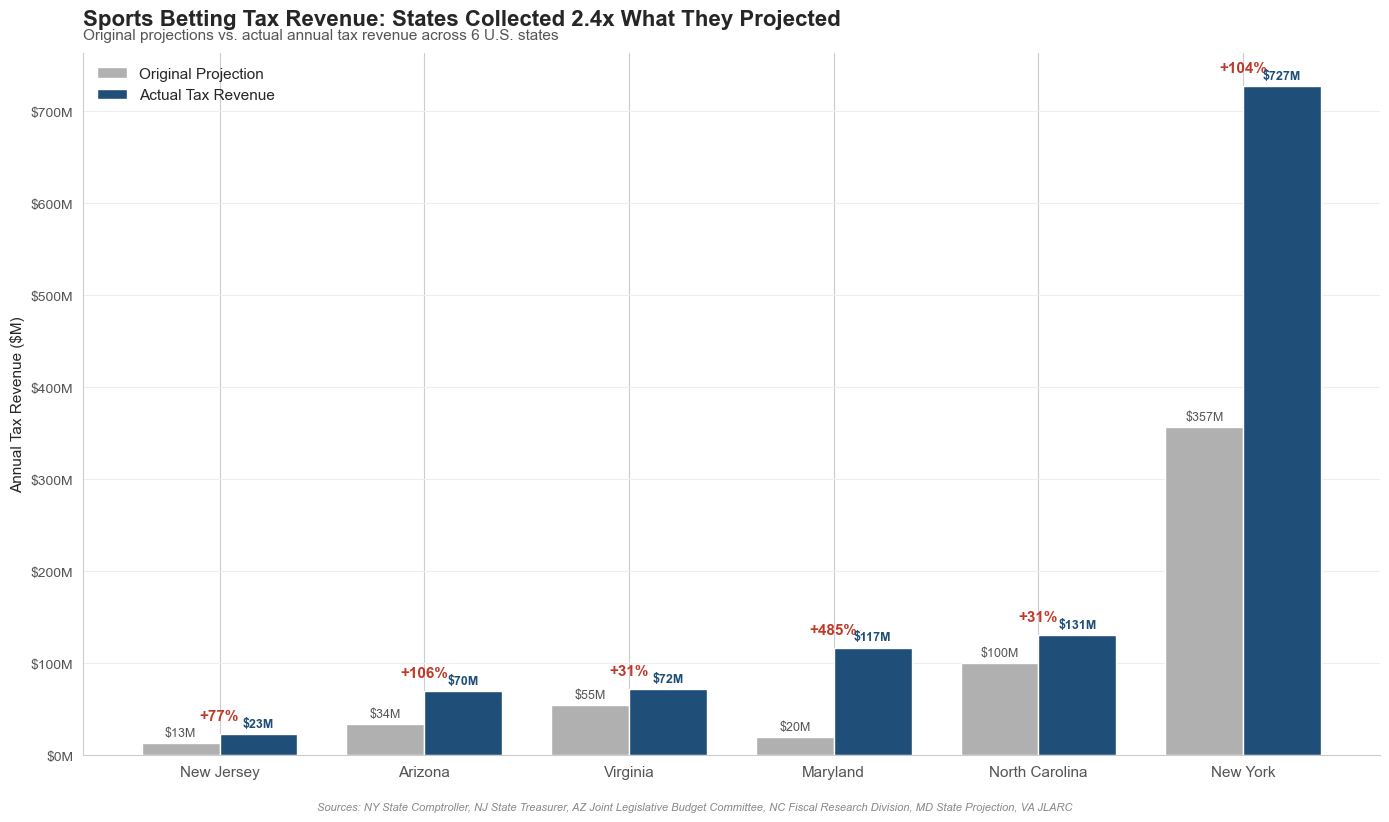


✓ Chart saved as 'projected_vs_actual_chart.png' in your notebook folder


In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Sort states by actual tax revenue for visual flow (smallest to largest)
df_sorted = df.sort_values("Actual Tax Revenue ($M)", ascending=True).reset_index(drop=True)

# Set up the figure
fig, ax = plt.subplots(figsize=(14, 8))

# Bar positioning
states = df_sorted["State"]
x = np.arange(len(states))
bar_width = 0.38

# Two sets of bars: projected and actual
projected_bars = ax.bar(x - bar_width/2, df_sorted["Projection ($M, mature year)"], 
                         bar_width, label="Original Projection", 
                         color="#B0B0B0", edgecolor="white", linewidth=1)
actual_bars = ax.bar(x + bar_width/2, df_sorted["Actual Tax Revenue ($M)"], 
                      bar_width, label="Actual Tax Revenue", 
                      color="#1F4E78", edgecolor="white", linewidth=1)

# Annotations: variance % above each pair
for i, (proj, actual, var) in enumerate(zip(
    df_sorted["Projection ($M, mature year)"],
    df_sorted["Actual Tax Revenue ($M)"],
    df_sorted["Variance vs Projection"]
)):
    max_val = max(proj, actual)
    ax.annotate(f"+{var:.0%}", 
                xy=(i, max_val), 
                xytext=(0, 8),
                textcoords="offset points",
                ha="center", va="bottom",
                fontsize=11, fontweight="bold", color="#C0392B")

# Value labels on each bar
for bar in projected_bars:
    height = bar.get_height()
    ax.annotate(f"${height:,.0f}M",
                xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points",
                ha="center", va="bottom", fontsize=9, color="#555555")

for bar in actual_bars:
    height = bar.get_height()
    ax.annotate(f"${height:,.0f}M",
                xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points",
                ha="center", va="bottom", fontsize=9, color="#1F4E78", fontweight="bold")

# Titles and labels
ax.set_title("Sports Betting Tax Revenue: States Collected 2.4x What They Projected",
             fontsize=16, fontweight="bold", pad=20, loc="left")
ax.text(0, 1.02, "Original projections vs. actual annual tax revenue across 6 U.S. states",
        transform=ax.transAxes, fontsize=11, color="#555555")

ax.set_ylabel("Annual Tax Revenue ($M)", fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(states, fontsize=11)
ax.legend(loc="upper left", frameon=False, fontsize=11)

# Clean up the look
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#CCCCCC")
ax.spines["bottom"].set_color("#CCCCCC")
ax.tick_params(axis="both", colors="#555555")
ax.yaxis.grid(True, color="#EEEEEE")
ax.set_axisbelow(True)

# Format y-axis with dollar signs
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}M"))

# Footer with source
plt.figtext(0.5, -0.02, 
            "Sources: NY State Comptroller, NJ State Treasurer, AZ Joint Legislative Budget Committee, "
            "NC Fiscal Research Division, MD State Projection, VA JLARC",
            ha="center", fontsize=8, color="#888888", style="italic")

plt.tight_layout()
plt.savefig("projected_vs_actual_chart.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

print("\n✓ Chart saved as 'projected_vs_actual_chart.png' in your notebook folder")

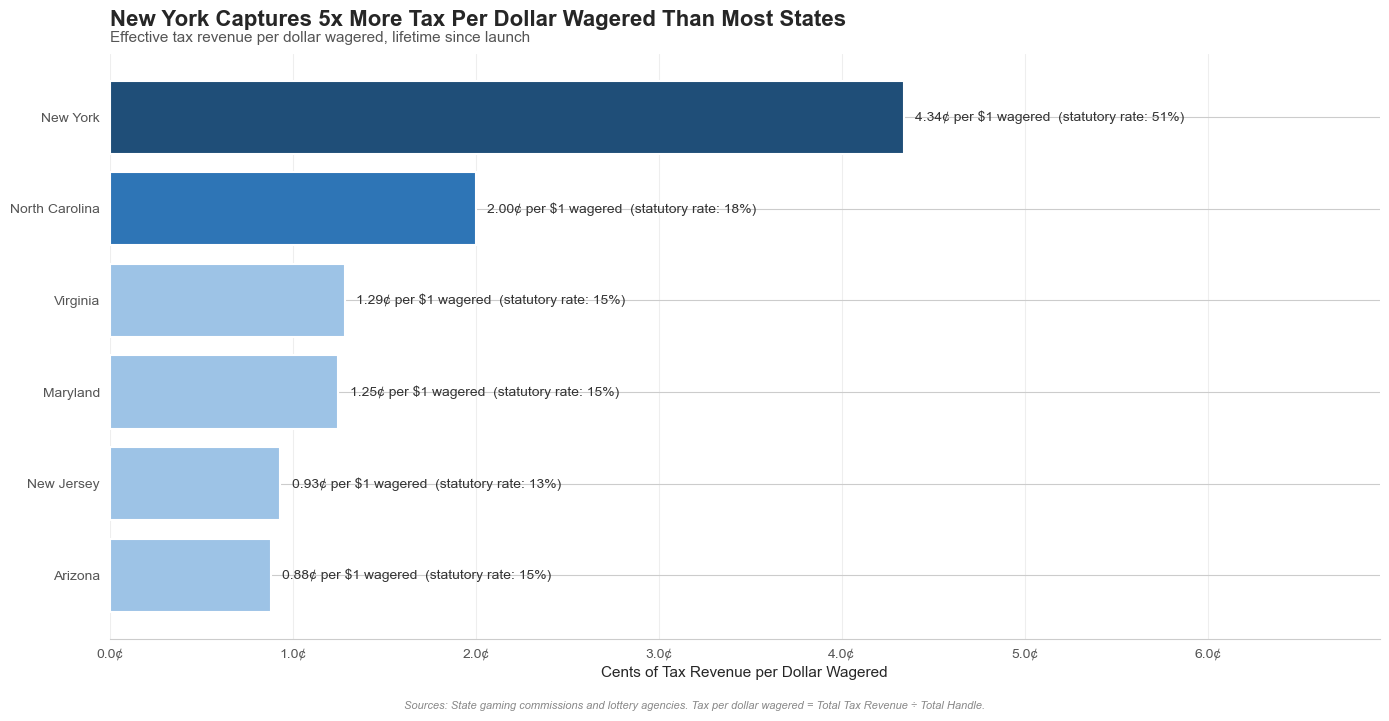


✓ Chart saved as 'tax_efficiency_chart.png' in your notebook folder


In [11]:
# Chart 2: Effective Tax Capture per Dollar Wagered

# Sort by tax per dollar wagered, descending
df_sorted_2 = df.sort_values("Tax per $ Wagered", ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(14, 7))

# Color states by tax rate tier
colors = []
for rate in df_sorted_2["Tax Rate"]:
    if rate >= 0.40:
        colors.append("#1F4E78")  # Navy for high tax
    elif rate >= 0.18:
        colors.append("#2E75B6")  # Medium blue
    else:
        colors.append("#9DC3E6")  # Light blue for low tax

# Horizontal bar chart
bars = ax.barh(df_sorted_2["State"], df_sorted_2["Tax per $ Wagered"] * 100,
               color=colors, edgecolor="white", linewidth=1.5)

# Annotate each bar with the value AND the statutory tax rate
for i, (bar, state, rate) in enumerate(zip(bars, df_sorted_2["State"], df_sorted_2["Tax Rate"])):
    width = bar.get_width()
    ax.annotate(f"{width:.2f}¢ per $1 wagered  (statutory rate: {rate:.0%})",
                xy=(width, bar.get_y() + bar.get_height()/2),
                xytext=(8, 0), textcoords="offset points",
                ha="left", va="center", fontsize=10, color="#333333")

# Title
ax.set_title("New York Captures 5x More Tax Per Dollar Wagered Than Most States",
             fontsize=16, fontweight="bold", pad=20, loc="left")
ax.text(0, 1.02, "Effective tax revenue per dollar wagered, lifetime since launch",
        transform=ax.transAxes, fontsize=11, color="#555555")

ax.set_xlabel("Cents of Tax Revenue per Dollar Wagered", fontsize=11)
ax.set_xlim(0, max(df_sorted_2["Tax per $ Wagered"] * 100) * 1.6)  # Extra space for labels

# Clean up the look
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_color("#CCCCCC")
ax.tick_params(axis="both", colors="#555555", left=False)
ax.xaxis.grid(True, color="#EEEEEE")
ax.set_axisbelow(True)

# Format x-axis as cents
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.1f}¢"))

# Footer with source
plt.figtext(0.5, -0.02,
            "Sources: State gaming commissions and lottery agencies. "
            "Tax per dollar wagered = Total Tax Revenue ÷ Total Handle.",
            ha="center", fontsize=8, color="#888888", style="italic")

plt.tight_layout()
plt.savefig("tax_efficiency_chart.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

print("\n✓ Chart saved as 'tax_efficiency_chart.png' in your notebook folder")

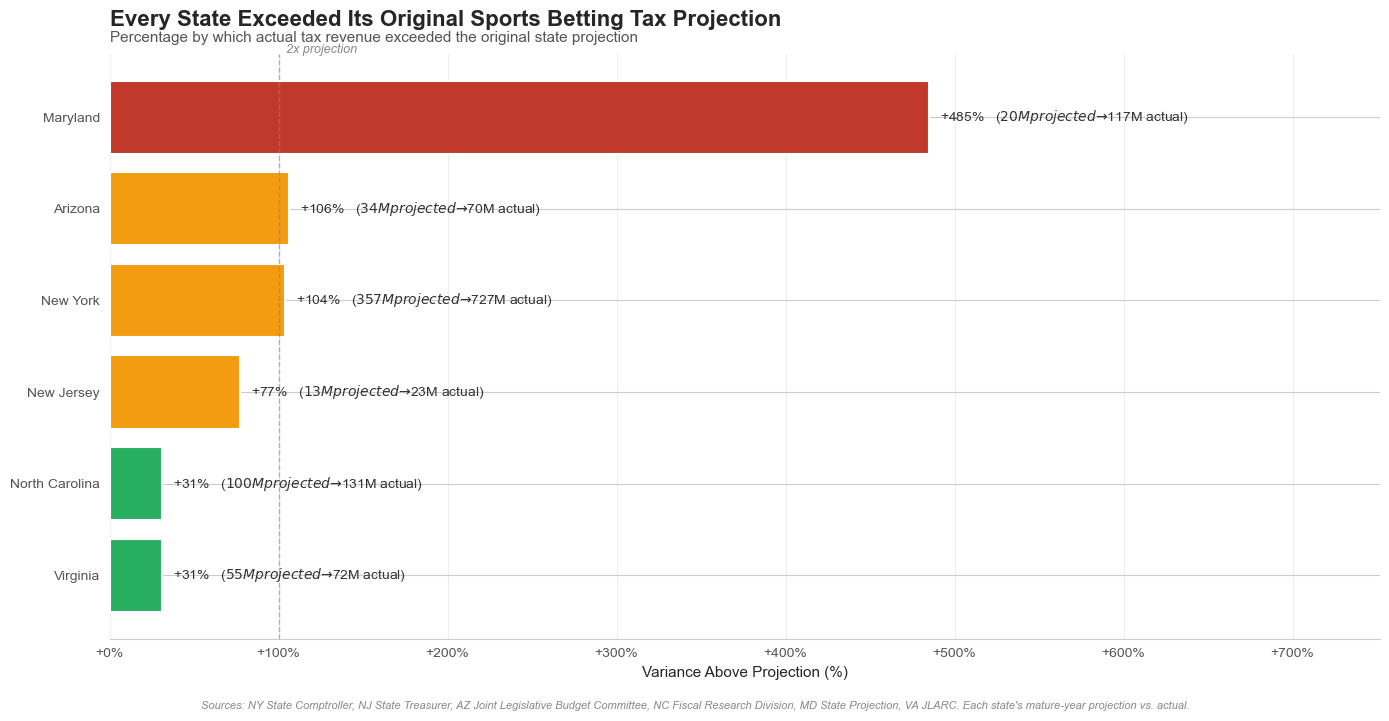


✓ Chart saved as 'variance_ranking_chart.png' in your notebook folder


In [12]:
# Chart 3: How Badly Did States Underestimate Tax Revenue?

# Sort by variance, descending (biggest miss at top)
df_sorted_3 = df.sort_values("Variance vs Projection", ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(14, 7))

# Color: gradient from green (close to projection) to red (far over)
colors = []
for var in df_sorted_3["Variance vs Projection"]:
    if var < 0.5:
        colors.append("#27AE60")   # Green — close to target
    elif var < 1.5:
        colors.append("#F39C12")   # Orange — significant miss
    else:
        colors.append("#C0392B")   # Red — massive miss

# Horizontal bar chart
bars = ax.barh(df_sorted_3["State"], df_sorted_3["Variance vs Projection"] * 100,
               color=colors, edgecolor="white", linewidth=1.5)

# Add 100% reference line (where actual would be 2x projected)
ax.axvline(x=100, color="#888888", linestyle="--", linewidth=1, alpha=0.6)
ax.text(100, len(df_sorted_3) - 0.3, "  2x projection", 
        fontsize=9, color="#888888", style="italic")

# Annotate each bar with variance and dollar amounts
for bar, state, var, proj, actual in zip(
    bars, df_sorted_3["State"], df_sorted_3["Variance vs Projection"],
    df_sorted_3["Projection ($M, mature year)"], df_sorted_3["Actual Tax Revenue ($M)"]
):
    width = bar.get_width()
    label = f"+{width:.0f}%   (${proj:,.0f}M projected → ${actual:,.0f}M actual)"
    ax.annotate(label,
                xy=(width, bar.get_y() + bar.get_height()/2),
                xytext=(8, 0), textcoords="offset points",
                ha="left", va="center", fontsize=10, color="#333333")

# Title
ax.set_title("Every State Exceeded Its Original Sports Betting Tax Projection",
             fontsize=16, fontweight="bold", pad=20, loc="left")
ax.text(0, 1.02, "Percentage by which actual tax revenue exceeded the original state projection",
        transform=ax.transAxes, fontsize=11, color="#555555")

ax.set_xlabel("Variance Above Projection (%)", fontsize=11)
ax.set_xlim(0, max(df_sorted_3["Variance vs Projection"] * 100) * 1.55)

# Clean up the look
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_color("#CCCCCC")
ax.tick_params(axis="both", colors="#555555", left=False)
ax.xaxis.grid(True, color="#EEEEEE")
ax.set_axisbelow(True)

# Format x-axis as percent
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"+{x:.0f}%"))

# Footer
plt.figtext(0.5, -0.02,
            "Sources: NY State Comptroller, NJ State Treasurer, AZ Joint Legislative Budget Committee, "
            "NC Fiscal Research Division, MD State Projection, VA JLARC. "
            "Each state's mature-year projection vs. actual.",
            ha="center", fontsize=8, color="#888888", style="italic")

plt.tight_layout()
plt.savefig("variance_ranking_chart.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

print("\n✓ Chart saved as 'variance_ranking_chart.png' in your notebook folder")

In [14]:
findings = """
================================================================================
KEY FINDINGS
================================================================================

HEADLINE FINDING
----------------
Across 6 U.S. states, sports betting tax revenue exceeded original projections
by an average of +138.9% - meaning states collected approximately 2.4x what
they originally projected when legalizing sports betting.

This was true for every single state in the analysis. Not one underperformed.


SUPPORTING FINDINGS
-------------------

1. MARYLAND'S PROJECTION WAS THE MOST INACCURATE (+485%)
   Maryland's official Question 2 referendum projected ~$20M annually in
   mature-year tax revenue. Actual collections reached ~$117M - nearly 6x
   the original estimate. The projection was made in 2020, before mobile
   betting's full impact was understood.

2. VIRGINIA AND NORTH CAROLINA PROJECTED MOST ACCURATELY (+31%)
   The most recent projections were the most realistic, likely because they
   could calibrate against actual data from earlier-legalizing states. VA's
   JLARC and NC's Fiscal Research Division both used live data from NJ and PA.

3. NORTH CAROLINA'S YEAR-1 REVENUE EXCEEDED ITS YEAR-4 PROJECTION
   NC projected ~$100M in tax revenue by FY 2027-28 (Year 4 of operation).
   NC reached $131M in Year 1 alone - a striking forecasting failure that
   highlights how quickly mobile-driven markets ramp.

4. TAX RATE DRAMATICALLY AFFECTS STATE CAPTURE
   New York's 51% statutory rate translates to ~4.3 cents of tax per dollar
   wagered - roughly 5x what New Jersey collects (0.93 cents) despite NJ
   having a comparable handle volume. New York alone accounts for 63.8% of
   combined annual tax revenue across the 6 states.

5. SPORTSBOOK HOLD RATES NEAR INDUSTRY STANDARDS (~8-9%)
   Most states show effective hold rates between 7.5% and 9% (industry
   standard). North Carolina's 11.1% is unusually high - likely because
   the market is newer and has not yet seen heavy promotional discounting.


COMBINED SCALE
--------------
- $227.5 billion total wagered across these 6 states since launch
- $19.2 billion kept by sportsbooks as revenue
- $5.24 billion collected by states in tax revenue


METHODOLOGY AND LIMITATIONS
---------------------------
Data sources: Primary government documents including the NY State Comptroller,
NJ State Treasurer, AZ Joint Legislative Budget Committee, NC General Assembly
Fiscal Research Division, MD State Projection (Question 2 referendum), and
VA Joint Legislative Audit and Review Commission. Actuals from state gaming
commissions. Cross-referenced against Tax Foundation, U.S. Census Bureau,
and Legal Sports Report.

Limitations:
- Projections made at different points in each state's legalization process
- AZ and MD actuals derived from approximation; primary-source verification
  recommended for final publication
- Analysis does not adjust for inflation between projection and actual dates


IMPLICATIONS
------------
The systematic underestimation of sports betting tax revenue across all six
states suggests that pre-launch fiscal projections likely underestimate
revenue potential, particularly when projections are made before mobile
betting's adoption pattern is established in comparable markets.

================================================================================
"""

print(findings)



KEY FINDINGS

HEADLINE FINDING
----------------
Across 6 U.S. states, sports betting tax revenue exceeded original projections
by an average of +138.9% - meaning states collected approximately 2.4x what
they originally projected when legalizing sports betting.

This was true for every single state in the analysis. Not one underperformed.


SUPPORTING FINDINGS
-------------------

1. MARYLAND'S PROJECTION WAS THE MOST INACCURATE (+485%)
   Maryland's official Question 2 referendum projected ~$20M annually in
   mature-year tax revenue. Actual collections reached ~$117M - nearly 6x
   the original estimate. The projection was made in 2020, before mobile
   betting's full impact was understood.

2. VIRGINIA AND NORTH CAROLINA PROJECTED MOST ACCURATELY (+31%)
   The most recent projections were the most realistic, likely because they
   could calibrate against actual data from earlier-legalizing states. VA's
   JLARC and NC's Fiscal Research Division both used live data from NJ and PA.

3

In [15]:
import os
print("Files in this notebook's folder:")
for f in os.listdir():
    if f.endswith('.png') or f.endswith('.ipynb') or f.endswith('.xlsx'):
        full_path = os.path.abspath(f)
        print(f"  {f}  →  {full_path}")

Files in this notebook's folder:
  projected_vs_actual_chart.png  →  C:\Users\xboxo\anaconda_projects\3d0008df-eff5-40ee-bd9c-2c11beb739f2\projected_vs_actual_chart.png
  SportsBetting.ipynb  →  C:\Users\xboxo\anaconda_projects\3d0008df-eff5-40ee-bd9c-2c11beb739f2\SportsBetting.ipynb
  tax_efficiency_chart.png  →  C:\Users\xboxo\anaconda_projects\3d0008df-eff5-40ee-bd9c-2c11beb739f2\tax_efficiency_chart.png
  variance_ranking_chart.png  →  C:\Users\xboxo\anaconda_projects\3d0008df-eff5-40ee-bd9c-2c11beb739f2\variance_ranking_chart.png
